# 🩺 Diabetes Prediction Training Pipeline

This notebook trains a PyTorch neural network to predict diabetes based on the Pima Indians Diabetes Database.

## Steps:
1. Load and explore data
2. Preprocess (handle missing values, normalization)
3. Define Neural Network Architecture
4. Train Model
5. Evaluate Accuracy
6. Save Model & Scaler for API deployment

In [47]:
!pip install kagglehub -q pandas scikit-learn torch matplotlib

In [48]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import json

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

## 1. Load Data

In [49]:
import kagglehub
import pandas as pd
import os

# Download latest version
print("📥 Downloading dataset via KaggleHub...")
path = kagglehub.dataset_download("mathchi/diabetes-data-set")
print("Path to dataset files:", path)

# Load the dataset
csv_path = os.path.join(path, "diabetes.csv")

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    print(f"✅ Dataset loaded successfully from: {csv_path}")
else:
    print(f"⚠️ 'diabetes.csv' not found directly in {path}. Searching for other CSVs...")
    # Fallback: Find any CSV in the folder
    csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
    if csv_files:
        csv_path = os.path.join(path, csv_files[0])
        df = pd.read_csv(csv_path)
        print(f"✅ Dataset loaded successfully from: {csv_path}")
    else:
        print("❌ No CSV files found in the download directory.")
        raise FileNotFoundError("No CSV file found in KaggleHub download")


# Verify dataset size
print(f"✅ Dataset Shape: {df.shape} (Rows, Columns)")
print(f"✅ Feature Columns: {list(df.columns)}")

# Show first 5 rows
df.head()

📥 Downloading dataset via KaggleHub...
Using Colab cache for faster access to the 'diabetes-data-set' dataset.
Path to dataset files: /kaggle/input/diabetes-data-set
✅ Dataset loaded successfully from: /kaggle/input/diabetes-data-set/diabetes.csv
✅ Dataset Shape: (768, 9) (Rows, Columns)
✅ Feature Columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 2. Preprocessing
Replace 0 values with mean for glucose, blood pressure, skin thickness, insulin, and BMI.

In [41]:
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in zero_cols:
    df[col] = df[col].replace(0, np.nan)
    mean_val = df[col].mean(skipna=True)
    df[col] = df[col].fillna(mean_val)
    
print("✅ Missing values handled.")

✅ Missing values handled.


In [50]:
# --- Data Imputation (Replace 0 with Median) ---
import numpy as np
cols_missing = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_missing] = df[cols_missing].replace(0, np.nan)
df.fillna(df.median(), inplace=True)
print('Imputed missing values (0s) with median.')

X = df.drop('Outcome', axis=1)
y = df['Outcome']


Imputed missing values (0s) with median.


In [51]:
# Convert to PyTorch Tensors
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train).unsqueeze(1)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.FloatTensor(y_test).unsqueeze(1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

## 3. Define Model

In [52]:
class DiabetesModel(nn.Module):
    def __init__(self, input_dim=8):
        super(DiabetesModel, self).__init__()
        self.layer1 = nn.Linear(input_dim, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.layer2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.layer3 = nn.Linear(64, 16)
        self.bn3 = nn.BatchNorm1d(16)
        self.layer4 = nn.Linear(16, 1)
        
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=0.3)
        # No Sigmoid here! BCEWithLogitsLoss handles it.
        
    def forward(self, x):
        x = self.relu(self.bn1(self.layer1(x)))
        x = self.dropout(x)
        x = self.relu(self.bn2(self.layer2(x)))
        x = self.dropout(x)
        x = self.relu(self.bn3(self.layer3(x)))
        x = self.layer4(x) # Linear output (logits)
        return x

model = DiabetesModel()
print(model)

DiabetesModel(
  (layer1): Linear(in_features=8, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer2): Linear(in_features=128, out_features=64, bias=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer3): Linear(in_features=64, out_features=16, bias=True)
  (bn3): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer4): Linear(in_features=16, out_features=1, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
)


## 4. Train Model

Epoch [20/400], Loss: 0.5810, Val Acc: 0.7273, LR: 0.001000
Epoch [40/400], Loss: 0.5463, Val Acc: 0.7208, LR: 0.001000
Epoch [60/400], Loss: 0.5483, Val Acc: 0.7273, LR: 0.001000
Epoch [80/400], Loss: 0.4822, Val Acc: 0.7273, LR: 0.001000
Epoch [100/400], Loss: 0.4952, Val Acc: 0.7208, LR: 0.001000
Epoch [120/400], Loss: 0.5154, Val Acc: 0.7403, LR: 0.001000
Epoch [140/400], Loss: 0.4833, Val Acc: 0.7273, LR: 0.000500
Epoch [160/400], Loss: 0.4635, Val Acc: 0.7273, LR: 0.000500
Epoch [180/400], Loss: 0.4520, Val Acc: 0.7338, LR: 0.000125
Epoch [200/400], Loss: 0.4282, Val Acc: 0.7143, LR: 0.000125
Epoch [220/400], Loss: 0.4423, Val Acc: 0.6753, LR: 0.000031
Epoch [240/400], Loss: 0.4133, Val Acc: 0.7078, LR: 0.000016
Epoch [260/400], Loss: 0.4726, Val Acc: 0.6883, LR: 0.000008
Epoch [280/400], Loss: 0.4585, Val Acc: 0.7078, LR: 0.000004
Epoch [300/400], Loss: 0.4448, Val Acc: 0.7273, LR: 0.000001
Epoch [320/400], Loss: 0.4647, Val Acc: 0.7078, LR: 0.000000
Epoch [340/400], Loss: 0.423

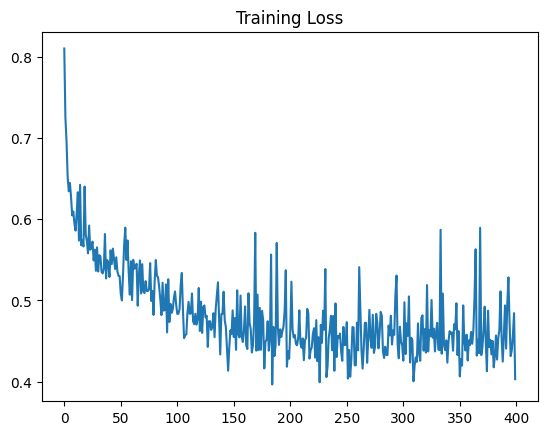

In [53]:
# Weighted Loss for Class Imbalance (~1.87)
pos_weight = torch.tensor([1.8]).float()
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=15)

epochs = 400
train_losses = []
best_acc = 0.0

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)
    
    model.eval()
    with torch.no_grad():
        y_logits = model(X_test_tensor)
        y_probs = torch.sigmoid(y_logits)
        y_pred_cls = y_probs.round()
        acc = (y_pred_cls.eq(y_test_tensor).sum() / float(y_test_tensor.shape[0])).item()
        
    scheduler.step(avg_loss)
    
    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(), 'diabetes_model.pth')
    
    if (epoch+1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}, Val Acc: {acc:.4f}, LR: {optimizer.param_groups[0]["lr"]:.6f}')

print(f"Best Validation Accuracy: {best_acc*100:.2f}%")
plt.plot(train_losses)
plt.title('Training Loss')
plt.show()

## 5. Evaluation

In [54]:
model.eval()
with torch.no_grad():
    y_pred_logits = model(X_test_tensor)
    y_probs = torch.sigmoid(y_pred_logits)
    y_pred_cls = y_probs.round()
    accuracy = (y_pred_cls.eq(y_test_tensor).sum() / float(y_test_tensor.shape[0])).item()
    print(f'Test Accuracy: {accuracy * 100:.2f}%')

Test Accuracy: 71.43%


## 6. Save Model

In [55]:
torch.save(model.state_dict(), 'diabetes_model.pth')
print("✅ Model saved to diabetes_model.pth")

✅ Model saved to diabetes_model.pth
